# Phase 4b — three sign architectures across the (hx, hz) plane

Relative energy error of the three sign-aware arms on the doubled semion,
graded against exact references (`results/diagnostics/signfid_*.json`,
`results/ed/ed_hc*_ds_*.json`). rel-err = |E_tail − E0|/|E0| with E_tail the
median of the last 20 training energies. Identical recipe everywhere: minSR,
lr 0.01, 350 steps, seed 0, 8192 samples. Only completed runs (`.mpack`
present) are shown; missing cells are grey (cnnqC runs still in the queue —
re-execute after the final fetch).

| arm | architecture |
|---|---|
| **cnnqB** | real trunk + QEC head (sign-framed Hamiltonian) |
| **cnnqC** | complex trunk + QEC head |
| **cnnqR** | real trunk + QEC head + tie-gated residual phase MLP |

Full numeric table incl. the ceiling columns (1−F_s, 1−F_plus): `python scripts/phase4b_summary.py`.

In [1]:
import os, sys, glob, re, pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# house plot style (shared with the toric-code-nqs repo)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGDIR = "figures"

ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / 'results' / 'nqs').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('run this notebook from inside the 2D-TC repo '
                           '(results/nqs not found walking up from the kernel cwd)')
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from scripts.phase4b_summary import load_refs, tail_stats

ARMS = ['cnnqB', 'cnnqC', 'cnnqR']
ARM_LABEL = {'cnnqB': 'B: real trunk + head',
             'cnnqC': 'C: complex trunk + head',
             'cnnqR': 'R: real trunk + head + residual'}
ARM_COLOR = {'cnnqB': '#0072B2', 'cnnqC': '#E69F00', 'cnnqR': '#009E73'}  # Okabe-Ito

refs = load_refs()
pat = re.compile(r'G-equiv_1_hc(\d+x\d+)_ds_(?:h0|hx([\d.]+)_hz([\d.]+))_(\w+)\.json$')
rel = {}
for f in glob.glob('results/nqs/G-equiv_1_hc*_ds_*.json'):
    if not os.path.exists(f.replace('.json', '.mpack')):
        continue                       # completed runs only
    m = pat.search(os.path.basename(f))
    if not m or m.group(4) not in ARMS or m.group(1) not in ('2x2', '2x3'):
        continue  # other sessions' sizes (e.g. 1x2 ladder sweeps) are out of scope here
    key = (m.group(1), round(float(m.group(2) or 0), 6), round(float(m.group(3) or 0), 6))
    e0 = refs.get(key, {}).get('E0')
    if e0:
        E, V, _, _, _ = tail_stats(f)
        rel[key + (m.group(4),)] = abs(E - e0) / abs(e0)
print(f'{len(rel)} completed graded runs loaded')

107 completed graded runs loaded


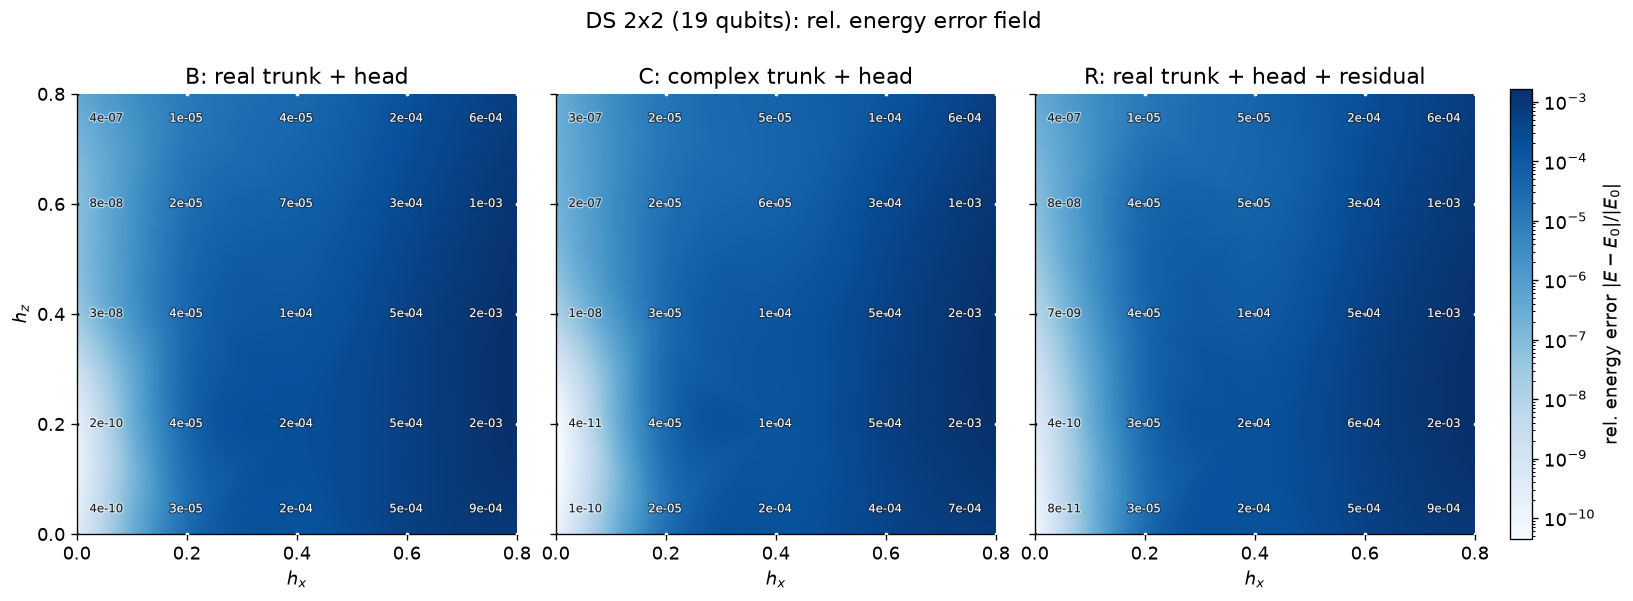

In [2]:
# 2x2: continuous error field per architecture (cubic interpolation in log10 space)
from scipy.interpolate import griddata
import matplotlib.patheffects as pe

VALS = [0.0, 0.2, 0.4, 0.6, 0.8]
pts, logv = {}, {}
for arm in ARMS:
    p, v = [], []
    for hz in VALS:
        for hx in VALS:
            r = rel.get(('2x2', hx, hz, arm))
            if r is not None:
                p.append((hx, hz)); v.append(np.log10(r))
    pts[arm], logv[arm] = np.array(p), np.array(v)

allv = np.concatenate(list(logv.values()))
vmin, vmax = allv.min(), allv.max()
norm = LogNorm(vmin=10**vmin, vmax=10**vmax)
g = np.linspace(0, 0.8, 161)
GX, GY = np.meshgrid(g, g)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True, constrained_layout=True)
for ax, arm in zip(axes, ARMS):
    ax.grid(False)
    F = np.clip(griddata(pts[arm], logv[arm], (GX, GY), method='cubic'), vmin, vmax)
    im = ax.imshow(10**np.ma.masked_invalid(F), origin='lower', extent=(0, 0.8, 0, 0.8),
                   cmap='Blues', norm=norm, interpolation='bilinear')
    ax.set_facecolor('0.88')
    # measured points stay annotated -- everything else is interpolation
    # (edge labels clamped inward so they don't collide with the axes)
    for (hx, hz), lv in zip(pts[arm], logv[arm]):
        dark = norm(10**lv) > 0.6
        col = 'white' if dark else '#1a1a1a'
        ax.plot(hx, hz, '.', ms=2.5, color=col, zorder=4)
        tx = min(max(hx, 0.055), 0.745)
        ty = min(max(hz, 0.045), 0.755)
        ax.text(tx, ty, f'{10**lv:.0e}', ha='center', va='center', fontsize=7,
                color=col, zorder=5,
                path_effects=[pe.withStroke(linewidth=1.6, alpha=0.5,
                              foreground='#1a1a1a' if dark else 'white')])
    ax.set_xticks(VALS); ax.set_yticks(VALS)
    ax.set(xlabel='$h_x$', title=ARM_LABEL[arm])
axes[0].set(ylabel='$h_z$')
cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.015)
cb.set_label(r'rel. energy error $|E - E_0|/|E_0|$')
fig.suptitle('DS 2x2 (19 qubits): rel. energy error field ', y=1.06)
fig.savefig(f"{FIGDIR}/phase4b_2x2_relerr.png", dpi=300, bbox_inches="tight")

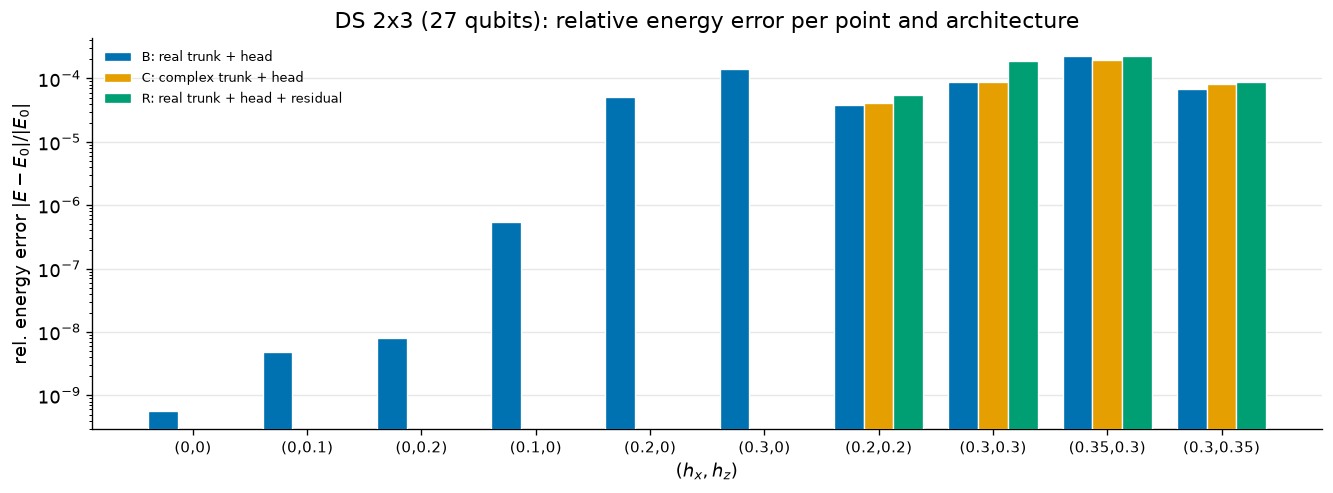

In [3]:
# 2x3 (27 qubits): all graded points, grouped bars per architecture
PTS = [(0.0, 0.0), (0.0, 0.1), (0.0, 0.2), (0.1, 0.0), (0.2, 0.0), (0.3, 0.0),
       (0.2, 0.2), (0.3, 0.3), (0.35, 0.3), (0.3, 0.35)]
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
w, x = 0.26, np.arange(len(PTS))
for k, arm in enumerate(ARMS):
    vals = [rel.get(('2x3', hx, hz, arm), np.nan) for hx, hz in PTS]
    ax.bar(x + (k - 1) * w, vals, w, color=ARM_COLOR[arm],
           label=ARM_LABEL[arm], edgecolor='white', linewidth=0.8, zorder=3)
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels([f'({hx:g},{hz:g})' for hx, hz in PTS], fontsize=9)
ax.set(xlabel='$(h_x, h_z)$', ylabel=r'rel. energy error $|E - E_0|/|E_0|$',
       title='DS 2x3 (27 qubits): relative energy error per point and architecture')
ax.grid(axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, loc='upper left')
# fig.savefig(f"{FIGDIR}/phase4b_2x3_relerr.png", dpi=300, bbox_inches="tight")

## Achieved error vs the deterministic-head ceiling

Each marker is one (point, architecture): x = the head's measured ceiling
1−F_s at that point (from the exact sign-fidelity diagnostics), y = the
achieved rel-err. The dashed guide is y = x: markers far above it are
optimization-limited (the sign head is not the bottleneck); markers near it
are head-limited. Points with ceiling exactly 0 (the hx = 0 column) are
clipped to the left edge (dotted line).

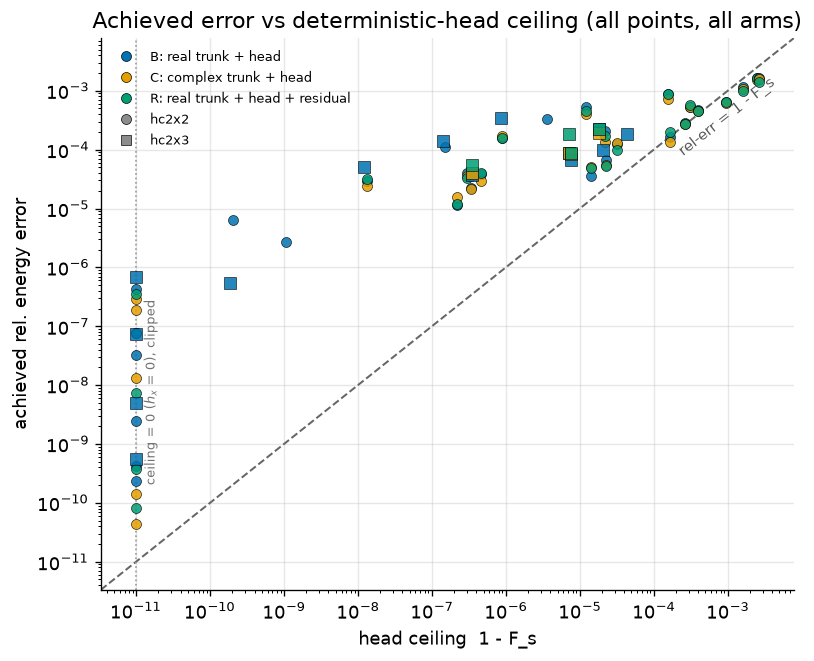

In [4]:
# achieved rel-err vs head ceiling (1 - F_s), log-log, y = x guide
from matplotlib.lines import Line2D

CLIP = 1e-11
MARK = {'2x2': 'o', '2x3': 's'}
xs, ys = [], []
fig, ax = plt.subplots(figsize=(6.6, 5.4), constrained_layout=True)
for (size, hx, hz, arm), y in sorted(rel.items()):
    fs = refs.get((size, hx, hz), {}).get('F_s')
    if fs is None:
        continue
    x = max(1.0 - fs, CLIP)
    xs.append(x); ys.append(y)
    ax.plot(x, y, MARK[size], color=ARM_COLOR[arm], ms=7 if size == '2x3' else 6,
            mec='k', mew=0.4, alpha=0.85, zorder=3)
lo = CLIP / 3
hi = 3 * max(max(xs), max(ys))
ax.plot([lo, hi], [lo, hi], '--', color='0.4', lw=1.2, zorder=2)
ax.text(2e-4, 8e-5, 'rel-err = 1 - F_s', color='0.35', fontsize=9, rotation=38)
ax.axvline(CLIP, color='0.6', ls=':', lw=1)
ax.text(CLIP * 1.3, 2e-10, 'ceiling = 0 ($h_x$ = 0), clipped', color='0.45',
        fontsize=8, rotation=90, va='bottom')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set(xlabel='head ceiling  1 - F_s', ylabel='achieved rel. energy error',
       title='Achieved error vs deterministic-head ceiling (all points, all arms)')
handles = [Line2D([], [], marker='o', ls='', color=ARM_COLOR[a], mec='k', mew=0.4,
                  ms=6, label=ARM_LABEL[a]) for a in ARMS]
handles += [Line2D([], [], marker=m, ls='', color='0.55', mec='k', mew=0.4, ms=6,
                   label=f'hc{s}') for s, m in MARK.items()]
ax.legend(handles=handles, frameon=False, fontsize=8, loc='upper left')
# fig.savefig(f"{FIGDIR}/phase4b_ceiling_scatter.png", dpi=300, bbox_inches="tight")

## Phase 4c — decoder-ladder head ceilings (2x2 + 2x3, exact)

The head's recovery rule is a dial: five deterministic decoders (`model/decoders.py`),
graded against the exact ground state (full $2^{19}$ / $2^{27}$ enumeration,
`scripts/sign_fidelity.py --decoders ...`) on the 3x3 grid $\{0, 0.4, 0.8\}^2$ at BOTH
ED-reachable sizes. $1 - F_s$ is each decoder's ceiling for ANY positive network x head ansatz.

- **$h_z$ axis: every decoder is exact at both sizes** (empty syndrome => empty recovery — the sector theorem is decoder-independent).
- **The ladder ordering holds at every field point and both sizes**: anchor << union-find < greedy < MWPM ~= tie-sum, spanning 2-4 orders.
- **Size dependence separates the mechanisms**: anchor GROWS with size ((0.4,0): 5.6e-3 -> 1.0e-2 — the extensive ~F·hx^2 channel), while MWPM stays ~size-independent (8.8e-7 -> 8.5e-7 — the tie channel), confirming the swarm-verified error taxonomy.
- **tie-sum ~= MWPM**: dominant tied classes cancel *exactly* (leading-order-undecidable => MWPM fallback); it separates only on the pure-$h_x$ axis (-40/-45% at (0.8,0)) and is slightly WORSE at $h_z \neq 0$ — the true tied signs live in unequal resolvent weights (the tie_sum_v2 design, see model/decoders.py).

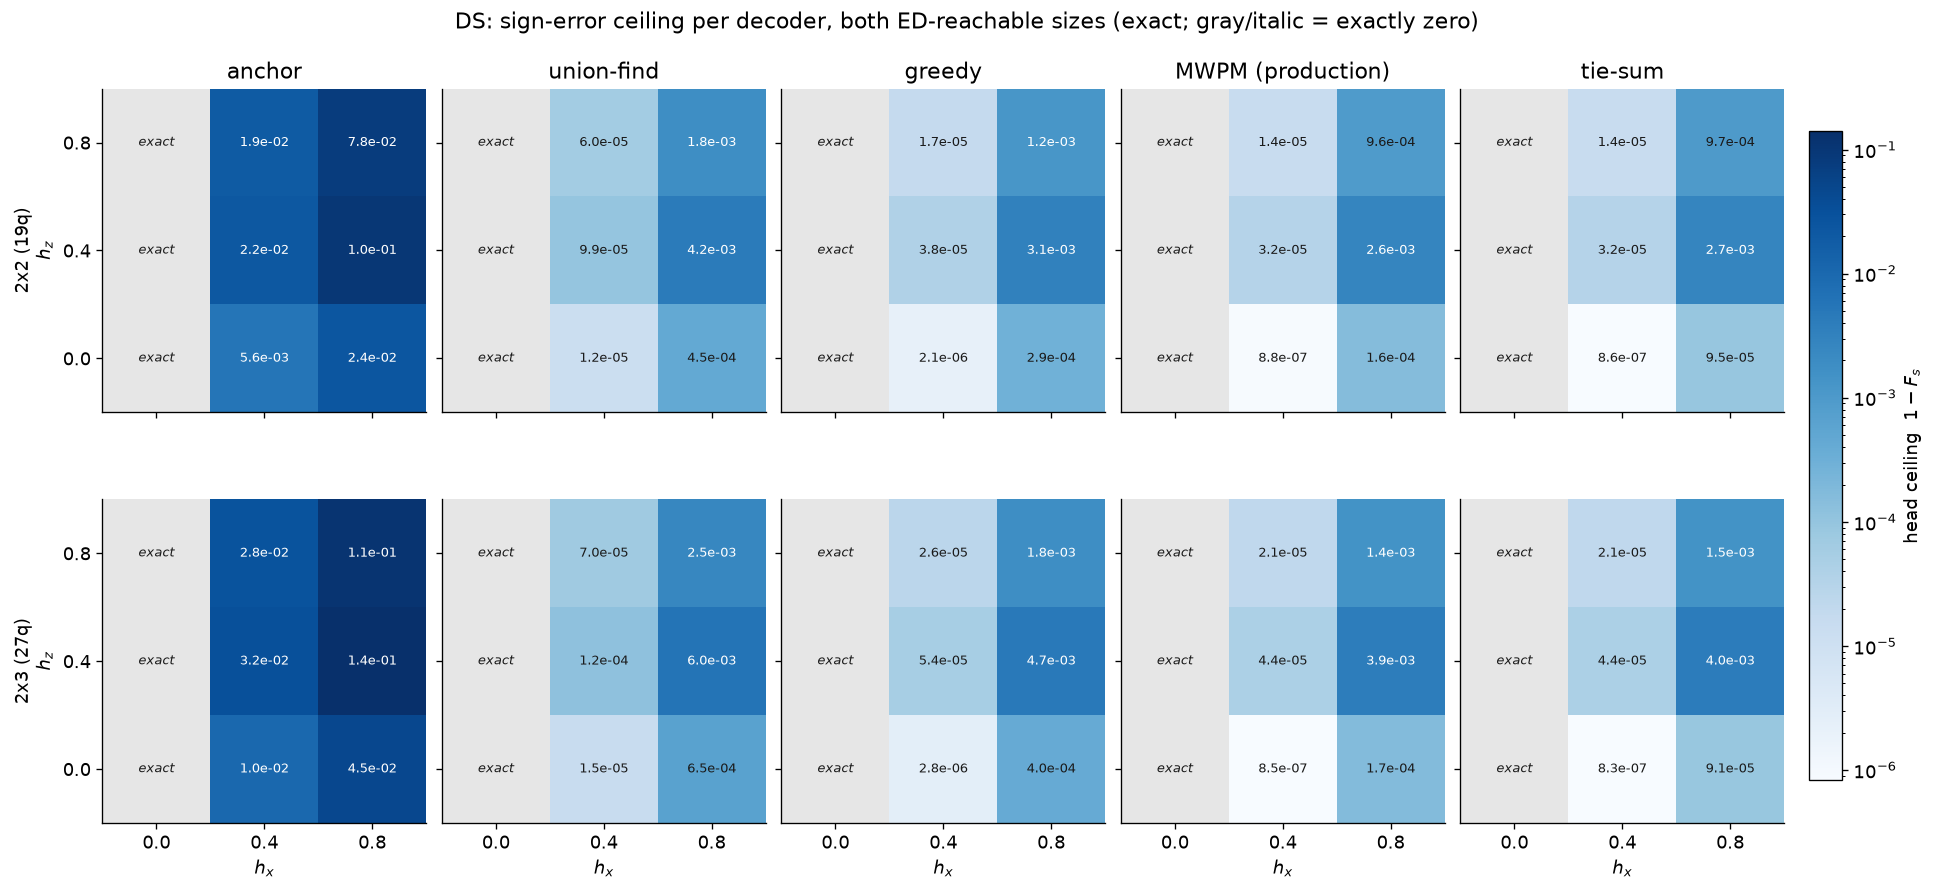

In [5]:
# Phase 4c: decoder-ladder ceilings, 3x3 grid, both sizes (exact grading)
import json, glob
DEC = ['anchor', 'unionfind', 'greedy', 'mwpm', 'tie_sum']
DEC_LABEL = {'anchor': 'anchor', 'unionfind': 'union-find', 'greedy': 'greedy',
             'mwpm': 'MWPM (production)', 'tie_sum': 'tie-sum'}
V3 = [0.0, 0.4, 0.8]

def load_ladder(files):
    wrong = {d: np.full((3, 3), np.nan) for d in DEC}      # [hz_idx, hx_idx]
    for f in files:
        for p in json.load(open(f))['points']:
            i, j = V3.index(p['hz']), V3.index(p['hx'])
            for d in DEC:
                wrong[d][i, j] = max(p['decoders'][d]['wrong_weight'], 0.0)
    return wrong

LADDER = {'2x2 (19q)': load_ladder(['results/diagnostics/signfid_hc2x2_ds_grid_dl.json']),
          '2x3 (27q)': load_ladder(sorted(glob.glob(
              'results/diagnostics/signfid_hc2x3_ds_*_dl.json')))}

pos = np.concatenate([w[w > 0] for L in LADDER.values() for w in L.values()])
norm = LogNorm(vmin=pos.min(), vmax=pos.max())
fig, axes = plt.subplots(2, 5, figsize=(16, 7.0), sharey=True, sharex=True,
                         constrained_layout=True)
for r, (size, wrong) in enumerate(LADDER.items()):
    for ax, d in zip(axes[r], DEC):
        ax.grid(False)
        W = np.ma.masked_less_equal(wrong[d], 0.0)         # exact points masked
        im = ax.imshow(W, origin='lower', extent=(-0.2, 1.0, -0.2, 1.0),
                       cmap='Blues', norm=norm, interpolation='nearest')
        ax.set_facecolor('0.9')
        for i, hz in enumerate(V3):
            for j, hx in enumerate(V3):
                v = wrong[d][i, j]
                if not np.isfinite(v):
                    continue
                if v <= 0:
                    ax.text(hx, hz, 'exact', ha='center', va='center',
                            fontsize=7.5, color='#1a1a1a', style='italic')
                else:
                    dark = norm(v) > 0.6
                    ax.text(hx, hz, f'{v:.1e}', ha='center', va='center',
                            fontsize=8, color='white' if dark else '#1a1a1a')
        ax.set_xticks(V3); ax.set_yticks(V3)
        if r == 0:
            ax.set(title=DEC_LABEL[d])
        if r == 1:
            ax.set(xlabel='$h_x$')
    axes[r][0].set(ylabel=f'{size}\n$h_z$')
cb = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.015)
cb.set_label(r'head ceiling  $1 - F_s$')
fig.suptitle('DS: sign-error ceiling per decoder, both ED-reachable sizes '
             '(exact; gray/italic = exactly zero)', y=1.04)
fig.savefig(f"{FIGDIR}/phase4c_decoder_ceilings.png", dpi=300, bbox_inches="tight")

Text(0.5, 0.98, 'DS decoder ladder at each field point ($h_z$-axis points exact for all five decoders)')

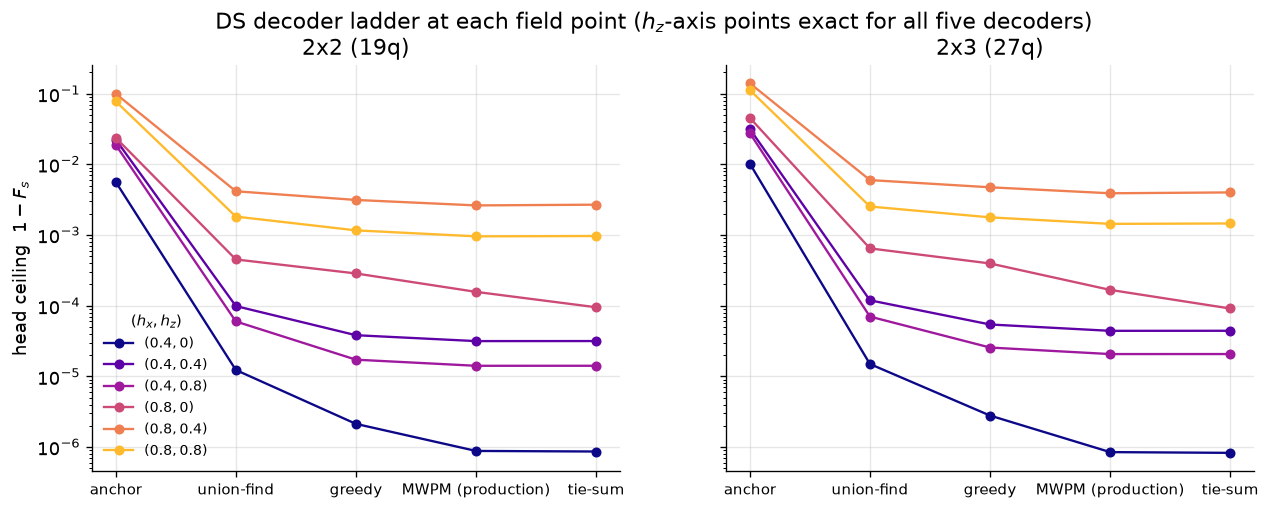

In [6]:
# same data as ladders: one panel per size, one line per field point
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
xs = np.arange(len(DEC))
cmap = plt.get_cmap('plasma')
for ax, (size, wrong) in zip(axes, LADDER.items()):
    pts_f = [(hx, hz) for hz in V3 for hx in V3 if hx > 0]
    for k, (hx, hz) in enumerate(sorted(pts_f)):
        i, j = V3.index(hz), V3.index(hx)
        ys = [wrong[d][i, j] for d in DEC]
        ax.plot(xs, ys, 'o-', ms=5, lw=1.4,
                color=cmap(0.85 * k / max(len(pts_f) - 1, 1)),
                label=f'$({hx:g}, {hz:g})$')
    ax.set_yscale('log')
    ax.set_xticks(xs)
    ax.set_xticklabels([DEC_LABEL[d] for d in DEC], fontsize=9)
    ax.set(title=size)
axes[0].set(ylabel='head ceiling  $1 - F_s$')
axes[0].legend(loc='lower left', frameon=False, fontsize=8.5,
               title='$(h_x, h_z)$', title_fontsize=9)
fig.suptitle('DS decoder ladder at each field point '
             '($h_z$-axis points exact for all five decoders)')
# fig.savefig(f"{FIGDIR}/phase4c_decoder_ladder.png", dpi=300, bbox_inches="tight")

## Phase 4c in vivo — 45 NQS runs at 2x3: does the decoder ceiling bite?

Full campaign: 9 grid points x 5 decoder arms (cnnqB trunk, Phase-3 recipe, 350 steps,
minSR, seed 0), graded against the exact E0s from the same diagnostic files as the
ceilings. The falsifiable question: does each decoder's exact sign-error ceiling
$1-F_s$ control the achieved NQS error?

- **$h_z$ axis: all five decoders TC-grade** (rel-err 1e-10..8e-7) — the sector theorem, in vivo, decoder-independently.
- **anchor is the only arm whose ceiling bites**: at every $h_x>0$ point its achieved error (4e-3..2e-2) sits at 14–68% of its ceiling and 10–30x the other arms — the negative control works.
- **mwpm ~= greedy ~= unionfind ~= tie_sum in vivo**: their ceilings (8e-7..6e-3) differ by up to 20x, but all four arms achieve the *same* error (~2e-4..3e-3), 1–2 orders above their ceilings — at this fixed 350-step budget the error is optimization-limited, so any decoder at unionfind grade or better is currently 'good enough', and decoder choice should be made on speed + 3D portability (see docs/decoder_scaling.md: MWPM wins).

45 graded runs


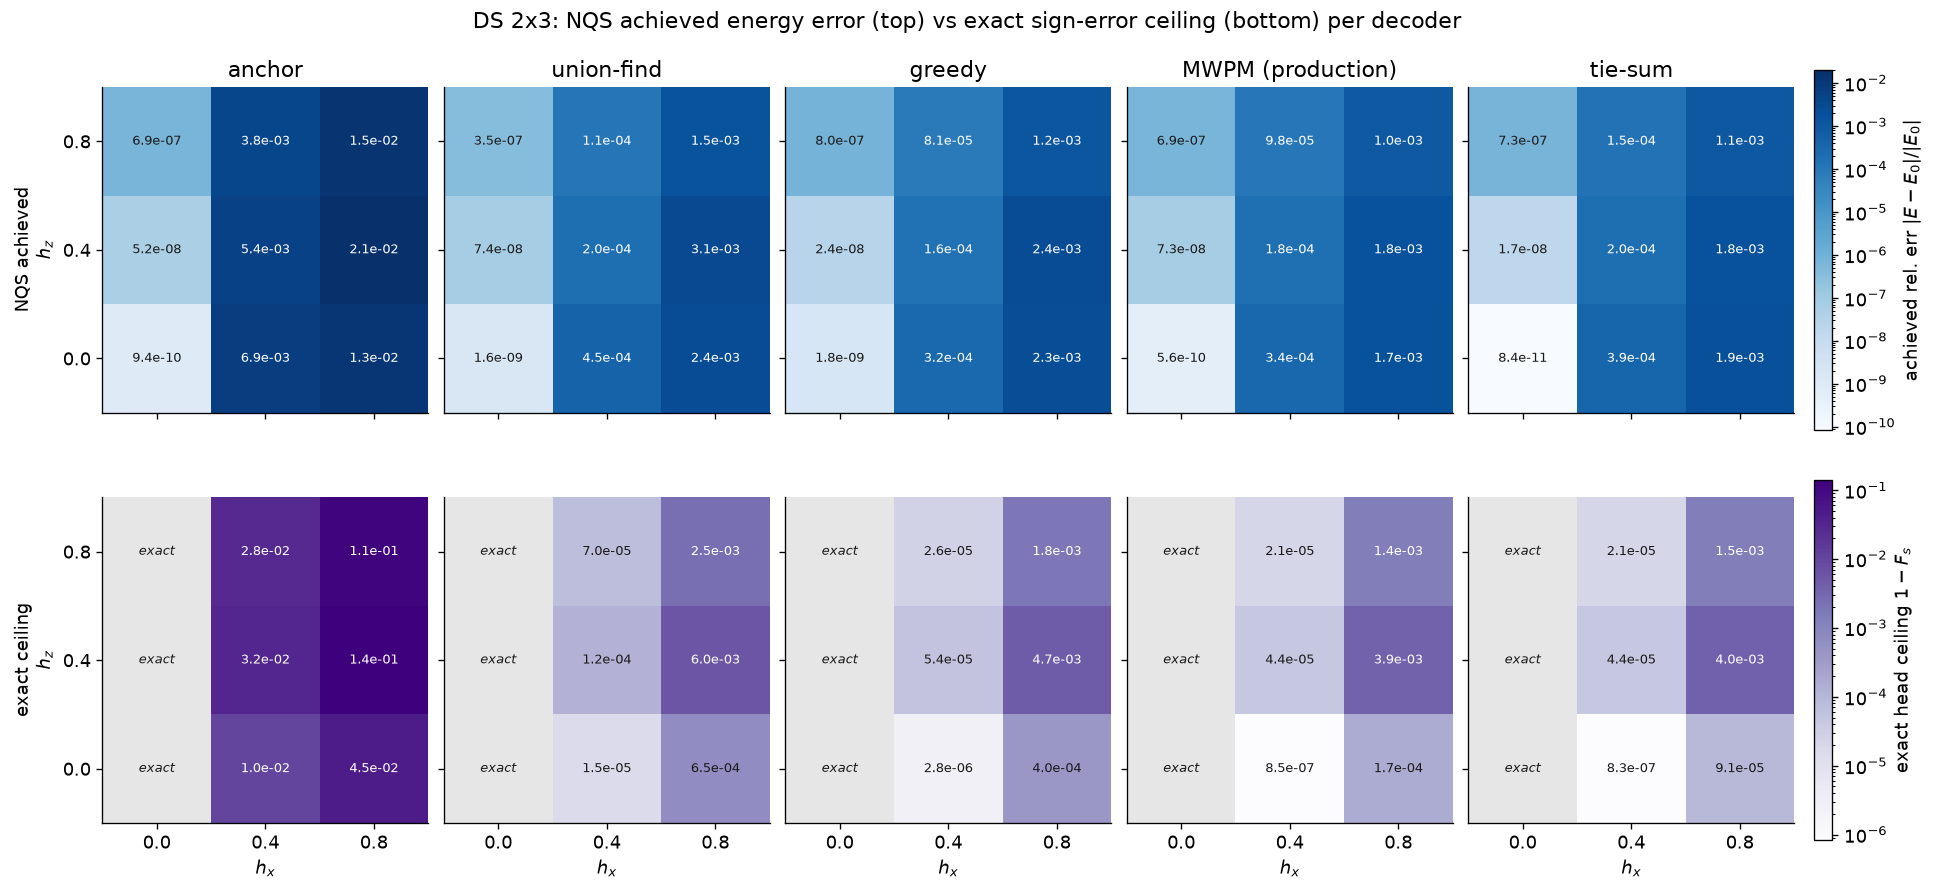

In [7]:
# Phase 4c in vivo at 2x3: achieved rel-err (top) vs exact head ceiling (bottom), per decoder
DEC_SUF = {'mwpm': '', 'anchor': '_anchor', 'greedy': '_greedy',
           'unionfind': '_unionfind', 'tie_sum': '_tie_sum'}
DEC_COLOR = {'anchor': '#D55E00', 'unionfind': '#CC79A7', 'greedy': '#009E73',
             'mwpm': '#0072B2', 'tie_sum': '#E69F00'}     # Okabe-Ito
refs4c = {}
for f in sorted(glob.glob('results/diagnostics/signfid_hc2x3_ds_*_dl.json')):
    for p in json.load(open(f))['points']:
        refs4c[(p['hx'], p['hz'])] = p
rel4c = {}
for (hx, hz), p in refs4c.items():
    for d in DEC:
        f = f"results/nqs/G-equiv_1_hc2x3_ds_hx{hx:g}_hz{hz:g}_cnnqB{DEC_SUF[d]}.json"
        if os.path.exists(f.replace('.json', '.mpack')):
            E, V, _, _, _ = tail_stats(f)
            rel4c[(hx, hz, d)] = abs(E - p['E0']) / abs(p['E0'])
print(f'{len(rel4c)} graded runs')

W_ach = {d: np.full((3, 3), np.nan) for d in DEC}
W_ceil = {d: np.full((3, 3), np.nan) for d in DEC}
for i, hz in enumerate(V3):
    for j, hx in enumerate(V3):
        for d in DEC:
            W_ach[d][i, j] = rel4c[(hx, hz, d)]
            W_ceil[d][i, j] = max(refs4c[(hx, hz)]['decoders'][d]['wrong_weight'], 0.0)

vals_a = np.array([w for d in DEC for w in W_ach[d].ravel()])
norm_a = LogNorm(vmin=vals_a.min(), vmax=vals_a.max())
vals_c = np.concatenate([W_ceil[d][W_ceil[d] > 0] for d in DEC])
norm_c = LogNorm(vmin=vals_c.min(), vmax=vals_c.max())

fig, axes = plt.subplots(2, 5, figsize=(16, 7.0), sharex=True, sharey=True,
                         constrained_layout=True)
for r, (W, norm_r, cmap_r) in enumerate([(W_ach, norm_a, 'Blues'),
                                         (W_ceil, norm_c, 'Purples')]):
    for ax, d in zip(axes[r], DEC):
        ax.grid(False)
        M = np.ma.masked_less_equal(W[d], 0.0)
        im = ax.imshow(M, origin='lower', extent=(-0.2, 1.0, -0.2, 1.0),
                       cmap=cmap_r, norm=norm_r, interpolation='nearest')
        ax.set_facecolor('0.9')
        for i, hz in enumerate(V3):
            for j, hx in enumerate(V3):
                v = W[d][i, j]
                if v <= 0:
                    ax.text(hx, hz, 'exact', ha='center', va='center',
                            fontsize=7.5, color='#1a1a1a', style='italic')
                else:
                    dark = norm_r(v) > 0.6
                    ax.text(hx, hz, f'{v:.1e}', ha='center', va='center',
                            fontsize=8, color='white' if dark else '#1a1a1a')
        ax.set_xticks(V3); ax.set_yticks(V3)
        if r == 0:
            ax.set(title=DEC_LABEL[d])
        else:
            ax.set(xlabel='$h_x$')
    cb = fig.colorbar(im, ax=list(axes[r]), shrink=0.9, pad=0.012)
    cb.set_label(r'achieved rel. err $|E-E_0|/|E_0|$' if r == 0
                 else r'exact head ceiling $1 - F_s$')
axes[0][0].set(ylabel='NQS achieved\n$h_z$')
axes[1][0].set(ylabel='exact ceiling\n$h_z$')
fig.suptitle('DS 2x3: NQS achieved energy error (top) vs exact sign-error ceiling '
             '(bottom) per decoder', y=1.04)
fig.savefig(f"{FIGDIR}/phase4c_2x3_invivo_vs_ceiling_heatmaps.png", dpi=300, bbox_inches="tight")

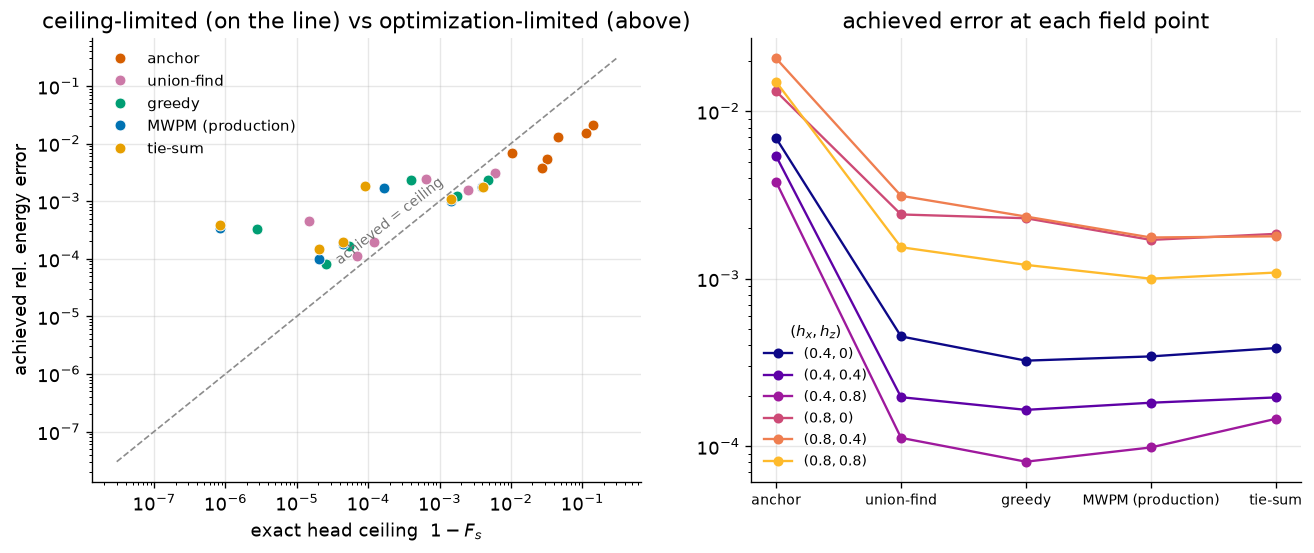

In [8]:
# achieved vs ceiling (left) + the six field points as a ladder (right)
fig, (axs, axl) = plt.subplots(1, 2, figsize=(13, 4.8))
pts_f = [(hx, hz) for hz in V3 for hx in V3 if hx > 0]
for d in DEC:
    xs_ = [max(refs4c[pt]['decoders'][d]['wrong_weight'], 1e-11) for pt in pts_f]
    ys_ = [rel4c[pt + (d,)] for pt in pts_f]
    axs.loglog(xs_, ys_, 'o', ms=6.5, mec='white', mew=0.5,
               color=DEC_COLOR[d], label=DEC_LABEL[d])
g = np.array([3e-8, 3e-1])
axs.plot(g, g, '--', color='0.55', lw=1)
axs.text(2e-4, 8e-5, 'achieved = ceiling', rotation=38, fontsize=8.5,
         color='0.45', ha='center')
axs.set(xlabel='exact head ceiling  $1 - F_s$',
        ylabel='achieved rel. energy error',
        title='ceiling-limited (on the line) vs optimization-limited (above)')
axs.legend(loc='upper left', frameon=False, fontsize=9)

xs = np.arange(len(DEC))
cmap = plt.get_cmap('plasma')
for k, (hx, hz) in enumerate(sorted(pts_f)):
    ys = [rel4c[(hx, hz, d)] for d in DEC]
    axl.plot(xs, ys, 'o-', ms=5, lw=1.4,
             color=cmap(0.85 * k / max(len(pts_f) - 1, 1)),
             label=f'$({hx:g}, {hz:g})$')
axl.set_yscale('log')
axl.set_xticks(xs)
axl.set_xticklabels([DEC_LABEL[d] for d in DEC], fontsize=8.5)
axl.set(title='achieved error at each field point')
axl.legend(loc='lower left', frameon=False, fontsize=8.5, title='$(h_x, h_z)$',
           title_fontsize=9)
# fig.savefig(f"{FIGDIR}/phase4c_2x3_invivo_ceiling.png", dpi=300, bbox_inches="tight")

## The architecture story in one plot — learning curves at the DS fixed point (2x3, h = 0)

Three tiers of the same experiment (identical optimizer/sampler/steps/seed; architecture is
the only variable): a plain CNN with no built-in structure cannot find topological order at
all; the approximately-symmetric Combo CNN finds it but is pinned at the **Hastings positivity
floor** (no positive-amplitude ansatz can go below it — a theorem, and the floor value is an
exact combinatorial optimum pre-registered before the runs); adding the deterministic **QEC
sign head** (Q_v syndrome -> MWPM recovery -> $(-1)^{\#loops}$) breaks through the floor to
the exact ground energy at $10^{-10}$ relative error, with zero trainable sign parameters.

The plain CNN's long flat stretch is not a training bug: at generic init the network
is the uniform-amplitude state $|+\rangle^{\otimes N}$ (MCMC acceptance exactly 1.000;
energy variance = V, the analytic uniform-state value), which for the DS Hamiltonian is
an $E \approx 0$ *plateau* — the optimizer escapes it stochastically (step ~212 at 2x2,
~322 at 2x3) and falls into a trivial attractor. The TC control confirms the mechanism:
there the same initial state is already the $E = -F$ local minimum, so TC-plaincnn starts
at $-F$ and never moves.

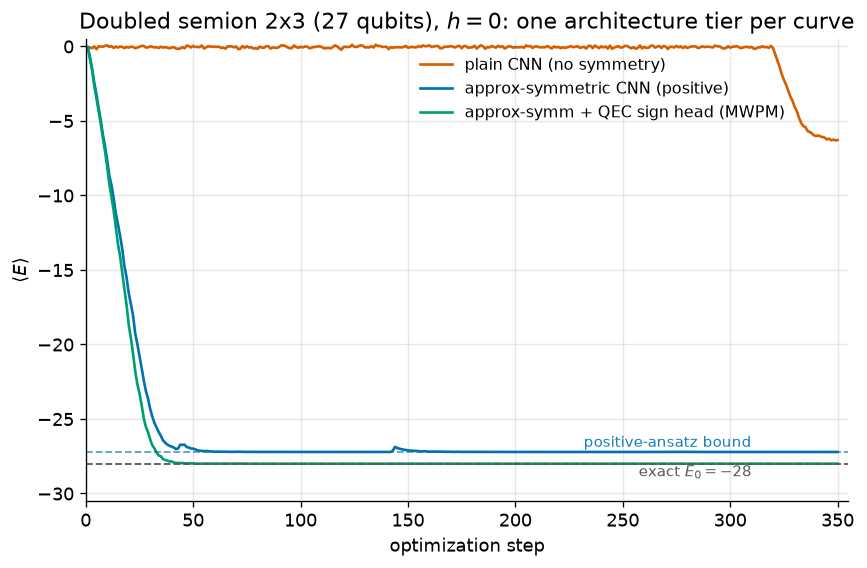

In [9]:
# learning curves: plain CNN vs approx-symm CNN vs approx-symm + QEC head (DS 2x3, h=0)
E0_2x3 = -28.0
FLOOR_2x3 = -27.2189973793          # exact positive-ansatz (Hastings) floor, pre-registered
TIERS = [('plaincnn', 'plain CNN (no symmetry)',            '#D55E00'),
         ('cnn',      'approx-symmetric CNN (positive)',    '#0072B2'),
         ('cnnqB',    'approx-symm + QEC sign head (MWPM)', '#009E73')]

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for arm, label, col in TIERS:
    tr = json.load(open(f'results/nqs/G-equiv_1_hc2x3_ds_h0_{arm}.json'))
    e = np.asarray(tr['energy'], dtype=float)
    ax.plot(np.arange(1, len(e) + 1), e, lw=1.6, color=col, label=label)
ax.axhline(FLOOR_2x3, ls='--', lw=1.1, color='#0072B2', alpha=0.65)
ax.axhline(E0_2x3, ls='--', lw=1.1, color='0.35')
ax.text(310, FLOOR_2x3 + 0.35, 'positive-ansatz bound',
        ha='right', fontsize=9, color='#0072B2', alpha=0.9)
ax.text(310, E0_2x3 - 0.9, 'exact $E_0 = -28$', ha='right', fontsize=9, color='0.35')
ax.set(xlabel='optimization step', ylabel=r'$\langle E \rangle$',
       title='Doubled semion 2x3 (27 qubits), $h = 0$: one architecture tier per curve',
       xlim=(0, 355), ylim=(-30.5, 0.5))
# ax.legend(loc='upper right', frameon=False, fontsize=9.5)
ax.legend(loc='upper left', bbox_to_anchor=(0.42, 0.99),
          frameon=False, fontsize=9.5)
fig.savefig(f"{FIGDIR}/phase4c_learning_curves_h0.png", dpi=300, bbox_inches="tight")

## Phase 4d — the decoder ladder with a $h_y$ field on (complex ground state)

Same 3x3 $(h_x, h_z)$ grid, now at $h_y = 0.4$: the honeycomb H becomes complex Hermitian,
the ground state carries genuine phases, and ALL arms run the complex trunk (cnnqC) on the
sign-framed $\tilde H$. Two changes of meaning vs the $h_y = 0$ sections:

- the exact ceiling is the **phase-optimized real-signed ceiling** — the best ANY positive
  net x $\pm 1$ head can do against a complex state (reduces exactly to $1-F_s$ at $h_y=0$);
  the complex trunk itself has NO expressivity ceiling, so achieved errors below the bottom
  row are possible and expected;
- the diagnostics predicted a **ceiling collapse**: mwpm = greedy = union-find = tie-sum to
  three digits at every point, anchor within 3% (hx = 0 column) to 1.6x (worst corner) —
  at $h_y \neq 0$ the ceiling is dominated by how complex the state is, not by recovery
  quality, so decoder choice should matter far less than at $h_y = 0$.

45/45 graded runs (missing points render gray)


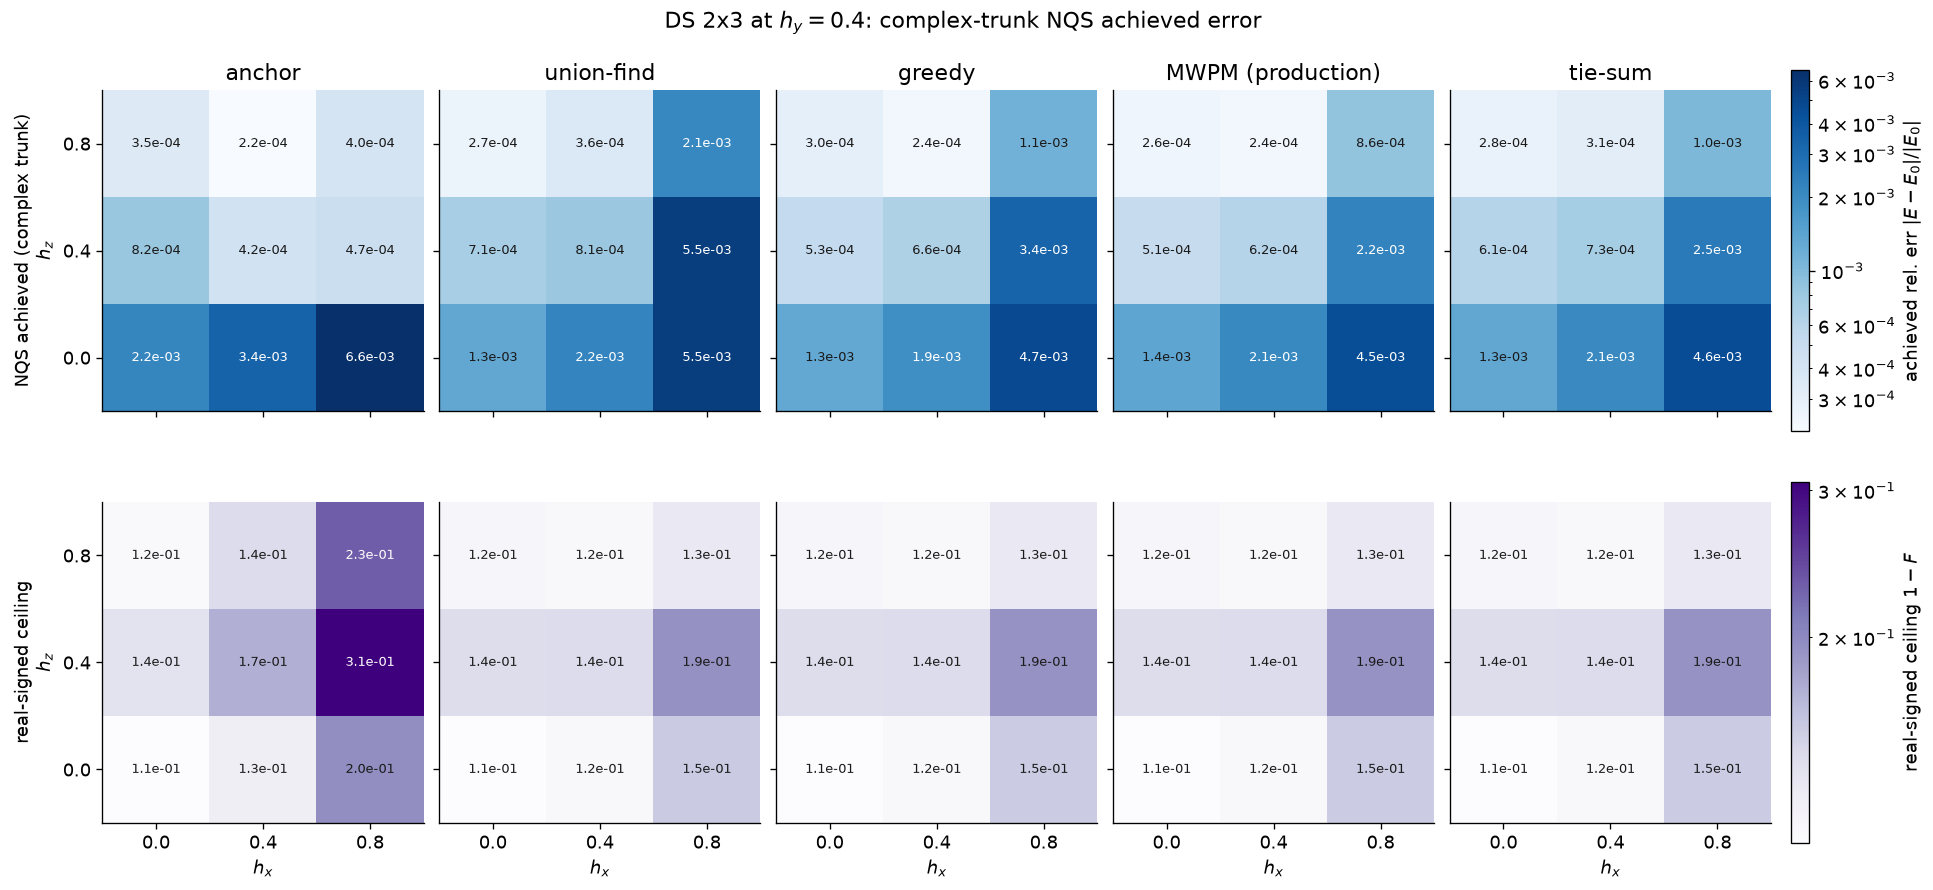

In [10]:
# Phase 4d in vivo at 2x3, hy=0.4: achieved rel-err (top) vs phase-optimized ceiling (bottom)
refs4d = {}
for f in sorted(glob.glob('results/diagnostics/signfid_hc2x3_ds_*_hy0.4.json')):
    for p in json.load(open(f))['points']:
        refs4d[(p['hx'], p['hz'])] = p
rel4d = {}
for (hx, hz), p in refs4d.items():
    for d in DEC:
        f = (f"results/nqs/G-equiv_1_hc2x3_ds_hx{hx:g}_hz{hz:g}_hy0.4_cnnqC"
             f"{DEC_SUF[d]}.json")
        if os.path.exists(f.replace('.json', '.mpack')):
            E, V, _, _, _ = tail_stats(f)
            rel4d[(hx, hz, d)] = abs(E - p['E0']) / abs(p['E0'])
print(f'{len(rel4d)}/45 graded runs (missing points render gray)')

W_ach = {d: np.full((3, 3), np.nan) for d in DEC}
W_ceil = {d: np.full((3, 3), np.nan) for d in DEC}
for i, hz in enumerate(V3):
    for j, hx in enumerate(V3):
        for d in DEC:
            if (hx, hz, d) in rel4d:
                W_ach[d][i, j] = rel4d[(hx, hz, d)]
            W_ceil[d][i, j] = refs4d[(hx, hz)]['decoders'][d]['wrong_weight']

va = np.array([v for d in DEC for v in W_ach[d].ravel() if np.isfinite(v)])
norm_a4 = LogNorm(vmin=va.min(), vmax=va.max())
vc = np.array([v for d in DEC for v in W_ceil[d].ravel()])
norm_c4 = LogNorm(vmin=vc.min(), vmax=vc.max())

fig, axes = plt.subplots(2, 5, figsize=(16, 7.0), sharex=True, sharey=True,
                         constrained_layout=True)
for r, (W, norm_r, cmap_r) in enumerate([(W_ach, norm_a4, 'Blues'),
                                         (W_ceil, norm_c4, 'Purples')]):
    for ax, d in zip(axes[r], DEC):
        ax.grid(False)
        M = np.ma.masked_invalid(W[d])
        im = ax.imshow(M, origin='lower', extent=(-0.2, 1.0, -0.2, 1.0),
                       cmap=cmap_r, norm=norm_r, interpolation='nearest')
        ax.set_facecolor('0.9')
        for i, hz in enumerate(V3):
            for j, hx in enumerate(V3):
                v = W[d][i, j]
                if not np.isfinite(v):
                    ax.text(hx, hz, 'pending', ha='center', va='center',
                            fontsize=7, color='#1a1a1a', style='italic')
                else:
                    dark = norm_r(v) > 0.6
                    ax.text(hx, hz, f'{v:.1e}', ha='center', va='center',
                            fontsize=8, color='white' if dark else '#1a1a1a')
        ax.set_xticks(V3); ax.set_yticks(V3)
        if r == 0:
            ax.set(title=DEC_LABEL[d])
        else:
            ax.set(xlabel='$h_x$')
    cb = fig.colorbar(im, ax=list(axes[r]), shrink=0.9, pad=0.012)
    cb.set_label(r'achieved rel. err $|E-E_0|/|E_0|$' if r == 0
                 else r'real-signed ceiling $1 - F$')
axes[0][0].set(ylabel='NQS achieved (complex trunk)\n$h_z$')
axes[1][0].set(ylabel='real-signed ceiling\n$h_z$')
fig.suptitle('DS 2x3 at $h_y = 0.4$: complex-trunk NQS achieved error ', y=1.04)
            #  'phase-optimized real-signed ceiling (bottom) per decoder', y=1.04)
fig.savefig(f"{FIGDIR}/phase4d_2x3_hy_invivo_vs_ceiling.png", dpi=300, bbox_inches="tight")

## Exact trained-state fidelities — the ground-truth metric for every campaign

Every run plotted above is now graded by its literal overlap with the exact ground state,
F = |<psi_ED | psi_NQS>|^2, computed by enumerating all 2^N configurations through the
trained network (rebuilt from each checkpoint; every record passes a built-in self-check
that recomputes <H> from the enumerated state and matches the run's logged energy).
Conventions: a *sign-free* state's fidelity ceiling is max(W+, W-) — a global flip is
free inside the modulus — which at the 2x3 fixed point is 0.75. The three-tier story in
those units: **plaincnn F = 0.0000022, positive cnn F = 0.664 (vs its 0.75 ceiling),
cnnqB F = 0.99998.** At hy = 0.4 the trained complex-trunk states reach F = 0.953-0.999,
all ABOVE the +-1-head class ceiling (~0.86-0.89) — and the trunk-only probe (head sign
stripped) collapses to F_trunk ~ 0.25, showing the complex trunk learned its phases ON TOP
of the head's discrete signs, not instead of them.

In [11]:
# fidelity loader: results/diagnostics/fidelity_hc*_p4*.json -> FID[(size, hy, hx, hz, arm)] = (F, F_trunk)
FID = {}
for f in sorted(glob.glob('results/diagnostics/fidelity_hc*_p4*.json')):
    d = json.load(open(f))
    size = f"{d['Lx']}x{d['Ly']}"
    for r in d['records']:
        assert r['energy_check_ok'], (f, r['arm'], r['hx'], r['hz'])
        FID[(size, r['hy'], r['hx'], r['hz'], r['arm'])] = (r['F'], r['F_trunk'])
print(f'{len(FID)} fidelity records, all energy-checked')

184 fidelity records, all energy-checked


Text(0.5, 1.06, 'DS 2x2: exact trained-state infidelity per arm (all 75 runs)')

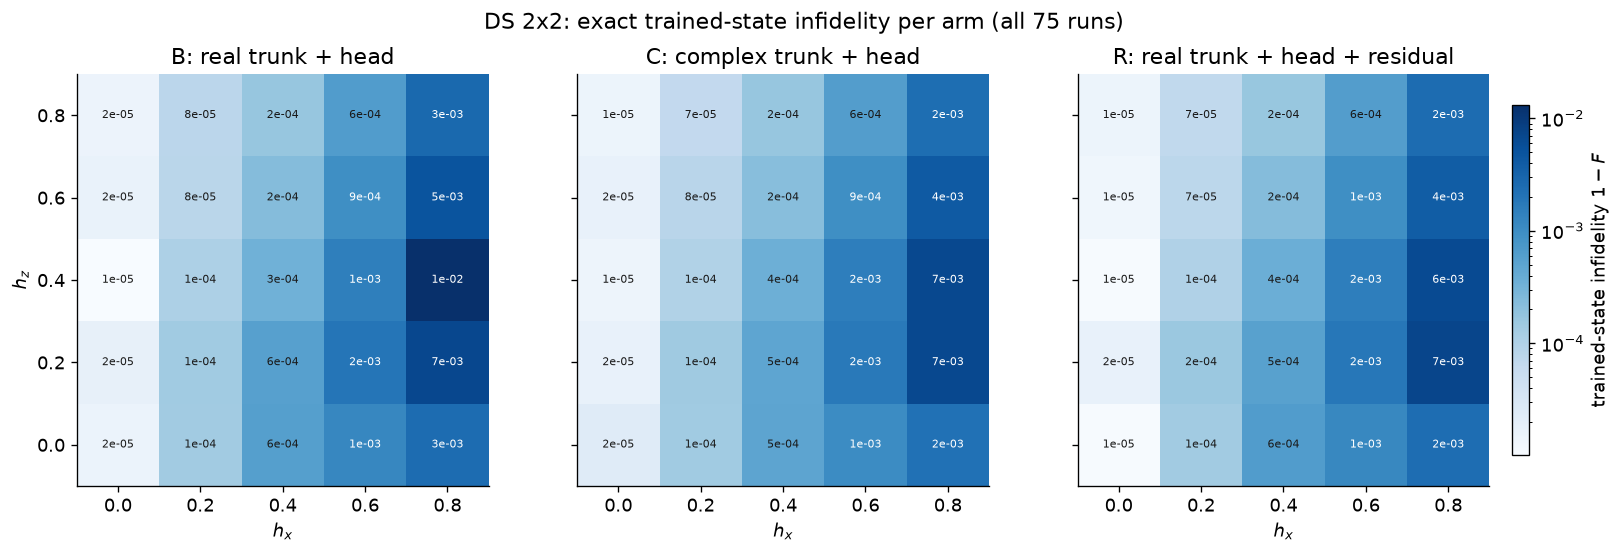

In [12]:
# 4b arms at 2x2: infidelity 1-F heatmaps (exact trained fidelities)
V5 = [0.0, 0.2, 0.4, 0.6, 0.8]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True, constrained_layout=True)
vals = [1 - FID[k][0] for k in FID if k[0] == '2x2']
norm_f = LogNorm(vmin=min(vals), vmax=max(vals))
for ax, arm in zip(axes, ARMS):
    ax.grid(False)
    W = np.full((5, 5), np.nan)
    for i, hz in enumerate(V5):
        for j, hx in enumerate(V5):
            k = ('2x2', 0.0, hx, hz, arm)
            if k in FID:
                W[i, j] = 1 - FID[k][0]
    im = ax.imshow(np.ma.masked_invalid(W), origin='lower',
                   extent=(-0.1, 0.9, -0.1, 0.9), cmap='Blues', norm=norm_f,
                   interpolation='nearest')
    ax.set_facecolor('0.9')
    for i, hz in enumerate(V5):
        for j, hx in enumerate(V5):
            if np.isfinite(W[i, j]):
                dark = norm_f(W[i, j]) > 0.6
                ax.text(hx, hz, f'{W[i, j]:.0e}', ha='center', va='center',
                        fontsize=6.5, color='white' if dark else '#1a1a1a')
    ax.set_xticks(V5); ax.set_yticks(V5)
    ax.set(xlabel='$h_x$', title=ARM_LABEL[arm])
axes[0].set(ylabel='$h_z$')
cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.015)
cb.set_label(r'trained-state infidelity $1 - F$')
fig.suptitle('DS 2x2: exact trained-state infidelity per arm (all 75 runs)', y=1.06)
# fig.savefig(f"{FIGDIR}/fidelity_4b_2x2.png", dpi=300, bbox_inches="tight")

Text(0.5, 1.06, 'DS 2x3 (hy=0), decoder arms: exact trained-state infidelity')

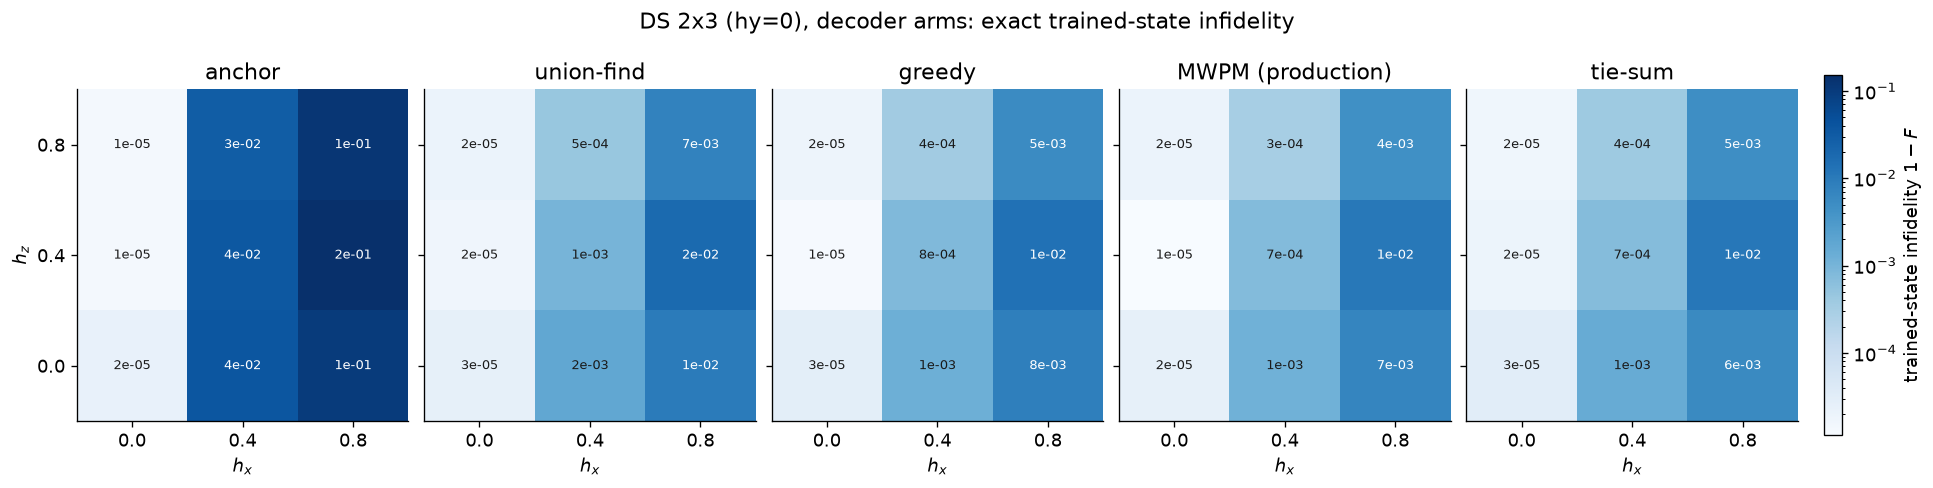

In [13]:
# 4c decoder ladder at 2x3 (hy=0): infidelity 1-F heatmaps
def dec_arm(base, d):
    return base if d == 'mwpm' else f'{base}_{d}'
fig, axes = plt.subplots(1, 5, figsize=(16, 3.7), sharey=True, constrained_layout=True)
vals = [1 - FID[('2x3', 0.0, hx, hz, dec_arm('cnnqB', d))][0]
        for d in DEC for hx in V3 for hz in V3
        if ('2x3', 0.0, hx, hz, dec_arm('cnnqB', d)) in FID]
norm_f = LogNorm(vmin=min(vals), vmax=max(vals))
for ax, d in zip(axes, DEC):
    ax.grid(False)
    W = np.full((3, 3), np.nan)
    for i, hz in enumerate(V3):
        for j, hx in enumerate(V3):
            k = ('2x3', 0.0, hx, hz, dec_arm('cnnqB', d))
            if k in FID:
                W[i, j] = 1 - FID[k][0]
    im = ax.imshow(np.ma.masked_invalid(W), origin='lower',
                   extent=(-0.2, 1.0, -0.2, 1.0), cmap='Blues', norm=norm_f,
                   interpolation='nearest')
    ax.set_facecolor('0.9')
    for i, hz in enumerate(V3):
        for j, hx in enumerate(V3):
            if np.isfinite(W[i, j]):
                dark = norm_f(W[i, j]) > 0.6
                ax.text(hx, hz, f'{W[i, j]:.0e}', ha='center', va='center',
                        fontsize=8, color='white' if dark else '#1a1a1a')
    ax.set_xticks(V3); ax.set_yticks(V3)
    ax.set(xlabel='$h_x$', title=DEC_LABEL[d])
axes[0].set(ylabel='$h_z$')
cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.015)
cb.set_label(r'trained-state infidelity $1 - F$')
fig.suptitle('DS 2x3 (hy=0), decoder arms: exact trained-state infidelity', y=1.06)
# fig.savefig(f"{FIGDIR}/fidelity_4c_2x3.png", dpi=300, bbox_inches="tight")

Text(0.5, 1.05, 'DS 2x3 at $h_y=0.4$: trained-state infidelity (top) and the head-contribution probe (bottom) — stripping the +-1 head collapses F to ~0.25, so the complex trunk learned phases ON TOP of the head signs')

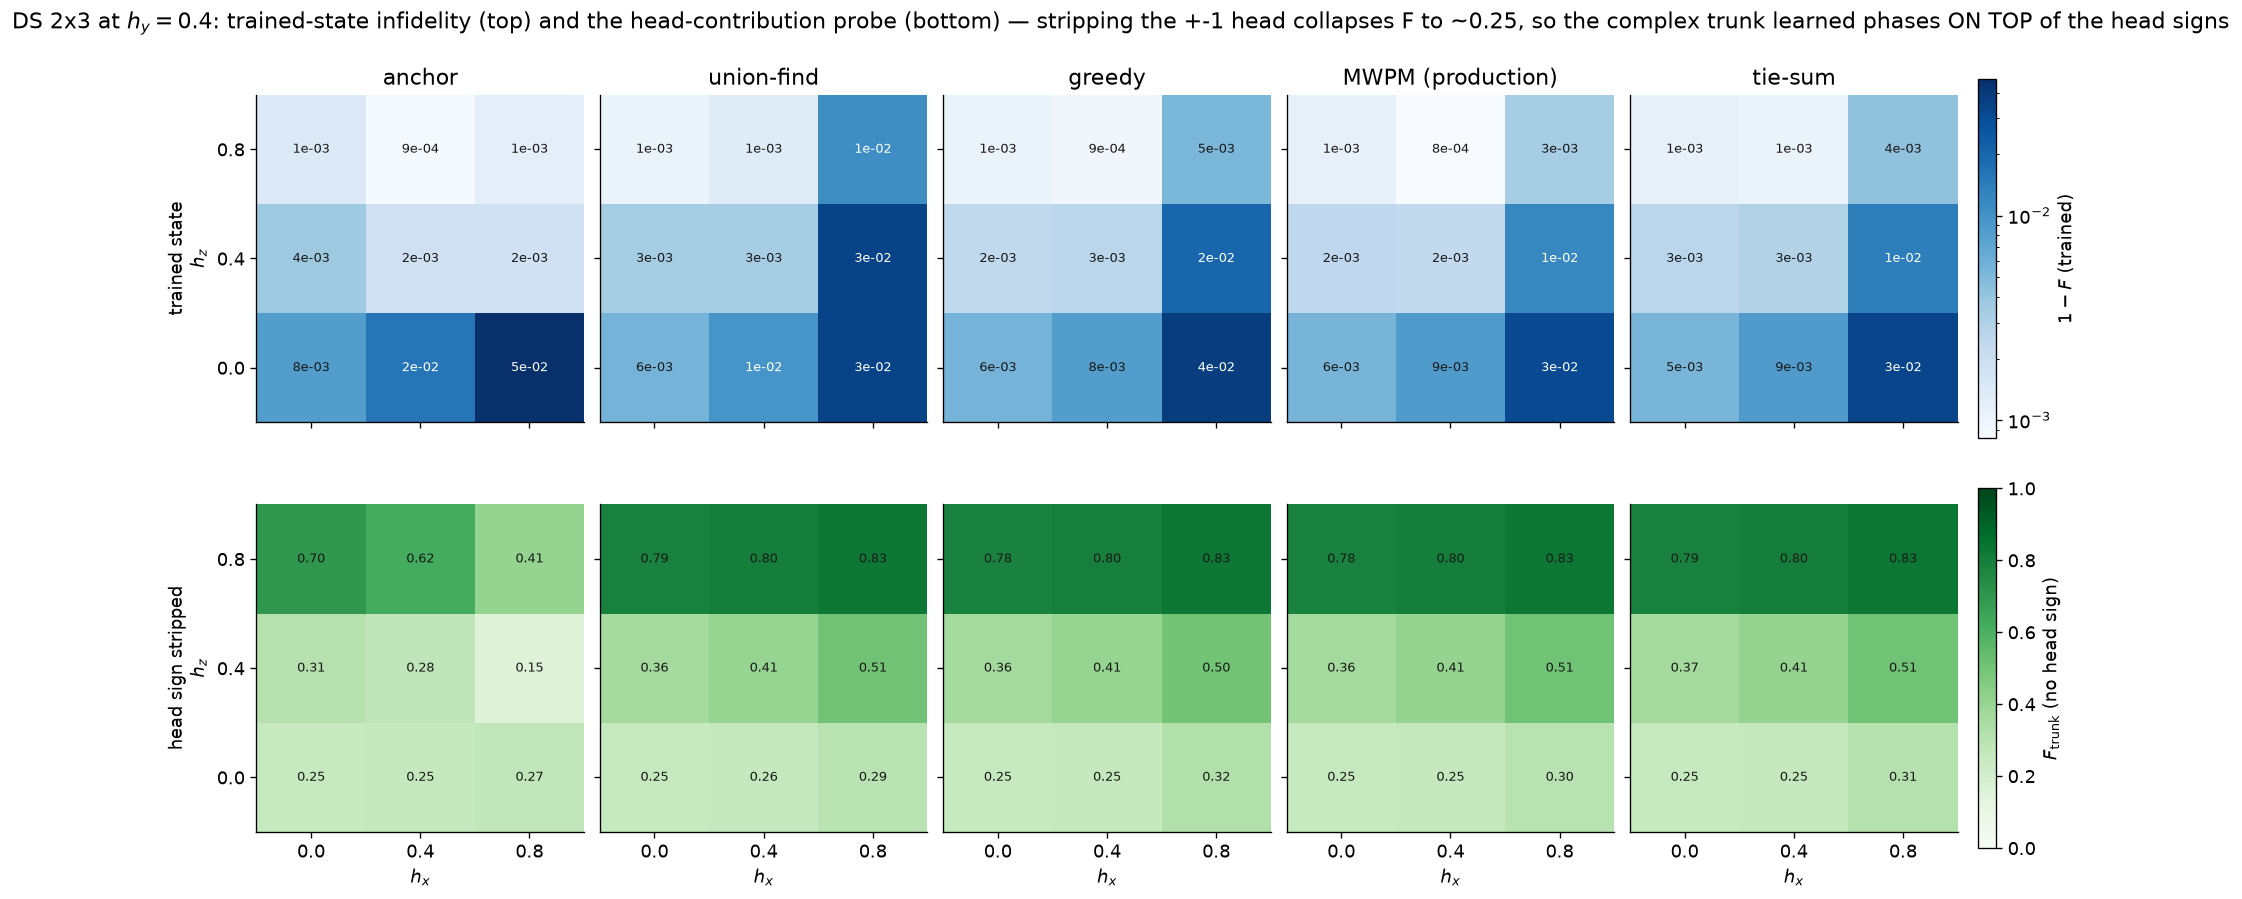

In [14]:
# 4d at hy=0.4: infidelity (top) + trunk-only fidelity F_trunk (bottom, head sign stripped)
fig, axes = plt.subplots(2, 5, figsize=(16, 7.0), sharex=True, sharey=True,
                         constrained_layout=True)
vals = [1 - FID[('2x3', 0.4, hx, hz, dec_arm('cnnqC', d))][0]
        for d in DEC for hx in V3 for hz in V3
        if ('2x3', 0.4, hx, hz, dec_arm('cnnqC', d)) in FID]
norm_f = LogNorm(vmin=min(vals), vmax=max(vals))
for ax, d in zip(axes[0], DEC):
    ax.grid(False)
    W = np.full((3, 3), np.nan)
    for i, hz in enumerate(V3):
        for j, hx in enumerate(V3):
            k = ('2x3', 0.4, hx, hz, dec_arm('cnnqC', d))
            if k in FID:
                W[i, j] = 1 - FID[k][0]
    im0 = ax.imshow(np.ma.masked_invalid(W), origin='lower',
                    extent=(-0.2, 1.0, -0.2, 1.0), cmap='Blues', norm=norm_f,
                    interpolation='nearest')
    for i, hz in enumerate(V3):
        for j, hx in enumerate(V3):
            if np.isfinite(W[i, j]):
                dark = norm_f(W[i, j]) > 0.6
                ax.text(hx, hz, f'{W[i, j]:.0e}', ha='center', va='center',
                        fontsize=8, color='white' if dark else '#1a1a1a')
    ax.set_xticks(V3); ax.set_yticks(V3)
    ax.set(title=DEC_LABEL[d])
for ax, d in zip(axes[1], DEC):
    ax.grid(False)
    W = np.full((3, 3), np.nan)
    for i, hz in enumerate(V3):
        for j, hx in enumerate(V3):
            k = ('2x3', 0.4, hx, hz, dec_arm('cnnqC', d))
            if k in FID and FID[k][1] is not None:
                W[i, j] = FID[k][1]
    im1 = ax.imshow(np.ma.masked_invalid(W), origin='lower',
                    extent=(-0.2, 1.0, -0.2, 1.0), cmap='Greens',
                    vmin=0.0, vmax=1.0, interpolation='nearest')
    for i, hz in enumerate(V3):
        for j, hx in enumerate(V3):
            if np.isfinite(W[i, j]):
                ax.text(hx, hz, f'{W[i, j]:.2f}', ha='center', va='center',
                        fontsize=8, color='#1a1a1a')
    ax.set_xticks(V3); ax.set_yticks(V3)
    ax.set(xlabel='$h_x$')
axes[0][0].set(ylabel='trained state\n$h_z$')
axes[1][0].set(ylabel='head sign stripped\n$h_z$')
cb0 = fig.colorbar(im0, ax=list(axes[0]), shrink=0.9, pad=0.012)
cb0.set_label(r'$1 - F$ (trained)')
cb1 = fig.colorbar(im1, ax=list(axes[1]), shrink=0.9, pad=0.012)
cb1.set_label(r'$F_{\rm trunk}$ (no head sign)')
fig.suptitle('DS 2x3 at $h_y=0.4$: trained-state infidelity (top) and the head-contribution '
             'probe (bottom) — stripping the +-1 head collapses F to ~0.25, so the '
             'complex trunk learned phases ON TOP of the head signs', y=1.05)
# fig.savefig(f"{FIGDIR}/fidelity_4d_2x3_hy.png", dpi=300, bbox_inches="tight")

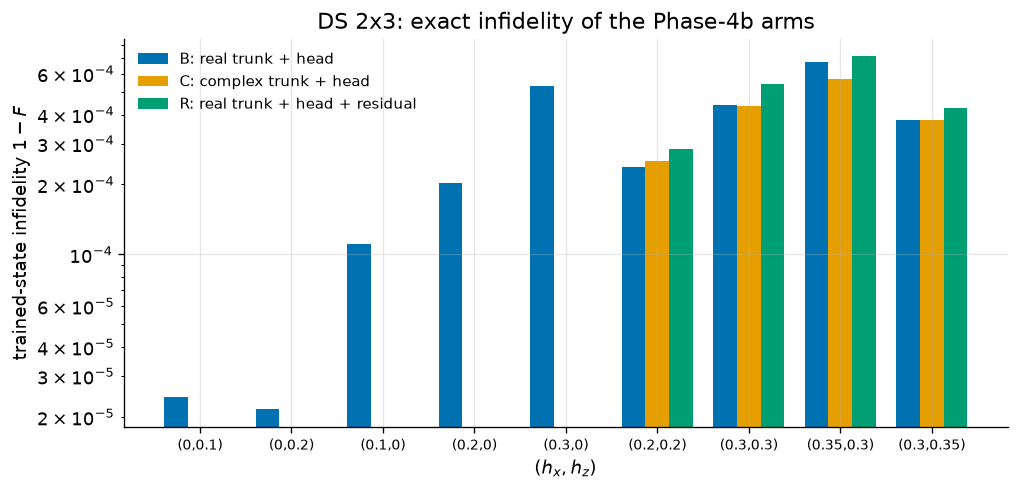

In [15]:
# 4b 2x3 points: fidelity bars (B/C/R) -- populated once the p4b3 fidelity job lands
PTS_43 = [(0.0,0.1),(0.0,0.2),(0.1,0.0),(0.2,0.0),(0.3,0.0),(0.2,0.2),(0.3,0.3),(0.35,0.3),(0.3,0.35)]
have = [(hx, hz) for (hx, hz) in PTS_43 if ('2x3', 0.0, hx, hz, 'cnnqB') in FID]
if not have:
    print('4b-2x3 fidelity job not fetched yet -- rerun this cell after it lands')
else:
    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    x = np.arange(len(have)); wdt = 0.26
    for o, arm in zip((-wdt, 0, wdt), ARMS):
        ys = [1 - FID[('2x3', 0.0, hx, hz, arm)][0]
              if ('2x3', 0.0, hx, hz, arm) in FID else np.nan for (hx, hz) in have]
        ax.bar(x + o, ys, wdt, color=ARM_COLOR[arm], label=ARM_LABEL[arm])
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels([f'({hx:g},{hz:g})' for (hx, hz) in have], fontsize=8.5)
    ax.set(xlabel='$(h_x, h_z)$', ylabel=r'trained-state infidelity $1 - F$',
           title='DS 2x3: exact infidelity of the Phase-4b arms')
    ax.legend(loc='upper left', frameon=False, fontsize=9)
# fig.savefig(f"{FIGDIR}/fidelity_4b_2x3_bars.png", dpi=300, bbox_inches="tight")